# **Extração dos Ficheiros**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shahpranshu27/rossman-store-sales/rossmann-store-sales/sample_submission.csv
/kaggle/input/datasets/shahpranshu27/rossman-store-sales/rossmann-store-sales/store.csv
/kaggle/input/datasets/shahpranshu27/rossman-store-sales/rossmann-store-sales/train.csv
/kaggle/input/datasets/shahpranshu27/rossman-store-sales/rossmann-store-sales/test.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
import os
os.makedirs("/kaggle/working/figures", exist_ok=True)

# **Milestone 1 - Exploração do Dataset**

In [4]:
base = "/kaggle/input/datasets/shahpranshu27/rossman-store-sales/rossmann-store-sales"

train = pd.read_csv(f"{base}/train.csv", dtype={"StateHoliday": str}, low_memory=False)
store = pd.read_csv(f"{base}/store.csv")

print("=== Dados Treino ===")
display(train.head())
print(' ')
print("\n=== Dados Loja ===")
display(store.head())

=== Dados Treino ===


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


 

=== Dados Loja ===


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
#Analise do Dataset
print("=== TRAIN ===")
print('Informação do Dataset')
train.info()
print(' ')
print('Descrição do Dataset')
train.describe()


=== TRAIN ===
Informação do Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
 
Descrição do Dataset


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
print("=== TRAIN ===")
print(train.isnull().sum())

print("\n=== STORE ===")
print(store.isnull().sum())

=== TRAIN ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

=== STORE ===
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


## Análise de Valores em Falta (Missing Values)

A verificação de nulos foi feita separadamente nas duas tabelas, por terem naturezas distintas.

**`train.csv`**: Não foram detetados valores em falta em nenhuma das 9 colunas 
(1 017 209 registos completos). Tratando-se de um histórico de vendas diárias, os dados 
estão íntegros, não sendo necessária qualquer imputação.

**`store.csv`**: Os valores em falta concentram-se nesta tabela e, ao contrário do 
habitual, não correspondem a erros de recolha, mas sim a ausência de evento (nulos 
com significado). A estratégia foi, por isso, definida coluna a coluna:

- **`CompetitionDistance`** (3 nulos): a ausência sugere que não há concorrente registado 
  nas proximidades. Será imputada pela mediana, por ser robusta a valores extremos 
  (há lojas com concorrentes muito distantes que enviesariam a média).
- **`CompetitionOpenSinceMonth` / `CompetitionOpenSinceYear`** (354 nulos cada): indicam 
  que se desconhece a data de abertura do concorrente. Serão preenchidas com 0, 
  representando "informação indisponível".
- **`Promo2SinceWeek` / `Promo2SinceYear` / `PromoInterval`** (544 nulos cada): estes 
  nulos ocorrem exatamente nas 544 lojas onde `Promo2 = 0`, ou seja, lojas que não 
  aderiram à promoção contínua. O nulo significa "não aplicável", pelo que serão 
  preenchidos com 0 (e a `PromoInterval` com a categoria "Nenhum"), preservando 
  essa informação.

**Decisão metodológica:** optou-se por não imputar indiscriminadamente pela média/mediana, 
porque na maioria dos casos o nulo é informação relevante. Imputar cegamente apagaria o 
sinal de que uma loja não tem concorrência próxima ou não participa numa promoção contínua.

In [7]:
# Confirmar o intervalo temporal real dos dados
train["Date"] = pd.to_datetime(train["Date"])

print("Data mais antiga:", train["Date"].min().date())
print("Data mais recente:", train["Date"].max().date())
print("Total de dias distintos:", train["Date"].nunique())

Data mais antiga: 2013-01-01
Data mais recente: 2015-07-31
Total de dias distintos: 942


In [8]:
# Conversão da coluna Date para o tipo datetime 
train["Date"] = pd.to_datetime(train["Date"])

print("Tipo da coluna Date:", train["Date"].dtype)
print("Período coberto:", train["Date"].min().date(), "a", train["Date"].max().date())

Tipo da coluna Date: datetime64[ns]
Período coberto: 2013-01-01 a 2015-07-31


---
## Resumo da Análise Inicial do Dataset (Encerramento Milestone 1)

A inspeção inicial dos dados nesta fase permite reunir as principais observações que vão orientar o resto do projeto.

### Observações estruturais

| Aspeto | Constatação | Implicação |
| :--- | :--- | :--- |
| Volume | 1 017 209 registos de vendas diárias (train) e 1 115 lojas (store) | Volume amplo, adequado a algoritmos de Machine Learning robustos. |
| Dimensionalidade | 9 colunas no train e 10 no store, combináveis por Store | Duas tabelas ligadas pela coluna da loja, que precisam de ser unidas antes da análise. |
| Integridade | Train sem nulos; nulos concentrados no store | Imputação necessária apenas no store, com estratégia por coluna. |
| Tipologia | Mistura de numéricas e categóricas (StoreType, Assortment, StateHoliday) | Exige encoding das categóricas antes da modelação. |
| Natureza temporal | A coluna Date cobre uma série diária por loja | Favorece variáveis de sazonalidade e impõe uma divisão treino e teste temporal. |

### Observações estatísticas relevantes

A variável alvo Sales apresenta assimetria positiva, com mínimo em 0 e máximo a rondar os 41 551, o que sugere testar uma transformação logarítmica na modelação.

Cerca de 17% dos registos correspondem a dias de loja fechada (Open igual a 0), nos quais as vendas são sempre nulas. Estes registos serão filtrados no treino do modelo de vendas.

A variável _Customers_ correlaciona-se com as vendas, mas não está disponível no conjunto de teste real, pelo que será usada apenas na análise exploratória e não como preditor.

Nos atributos de loja, os nulos não correspondem a erros mas sim a ausência de evento, como lojas sem concorrente próximo ou sem adesão à promoção contínua Promo2.

### Conclusões para as fases seguintes

1. Métricas: tratando-se de uma regressão, as métricas centrais serão o RMSPE e o MAE, rejeitando qualquer métrica de classificação.
2. Algoritmos: modelos baseados em árvores como Random Forest e XGBoost são preferíveis aos lineares, pela capacidade de captar relações não lineares e interações.
3. Divisão treino e teste: será feita de forma temporal, reservando as semanas finais para teste, de modo a evitar fugas de informação do futuro para o passado.
4. Engenharia de atributos: prevê-se a criação de variáveis de calendário e de histórico de vendas, a validar quanto à correlação com o alvo na Milestone 2.

Com o problema definido e os dados conhecidos, o projeto está pronto para avançar para a Análise Exploratória de Dados (Milestone 2).

# Milestone 2 - Exploração

## Junção de Tabelas (Preparação Inicial)

In [9]:
base = "/kaggle/input/datasets/shahpranshu27/rossman-store-sales/rossmann-store-sales"
train = pd.read_csv(f"{base}/train.csv", dtype={"StateHoliday": str}, low_memory=False)
store = pd.read_csv(f"{base}/store.csv")

# Converter a data 
train["Date"] = pd.to_datetime(train["Date"])

# Juntar as duas tabelas pela coluna Store (cada venda fica com as características da sua loja)
df = train.merge(store, on="Store", how="left")

print("Dimensão após junção:", df.shape)
df.head()

Dimensão após junção: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Os dados estão distribuídos por dois ficheiros: o _`train`_, com o histórico diário de vendas, e o _`store`_, com as características de cada loja. Para que cada registo de vendas fique associado às características da respetiva loja, as duas tabelas foram unidas pela coluna _`Store`_, comum a ambas.

Utilizou-se uma junção à esquerda (`left join`), que mantém todas as linhas do histórico de vendas e acrescenta a cada uma a informação da loja correspondente. Desta forma, o número de registos mantém-se em 1 017 209, confirmando que nenhuma venda foi perdida na junção.

Importa esclarecer que esta operação não altera nem cria variáveis. Trata-se apenas de consolidar num único conjunto a informação que estava separada por dois ficheiros, deixando os dados prontos para a análise exploratória que se segue.

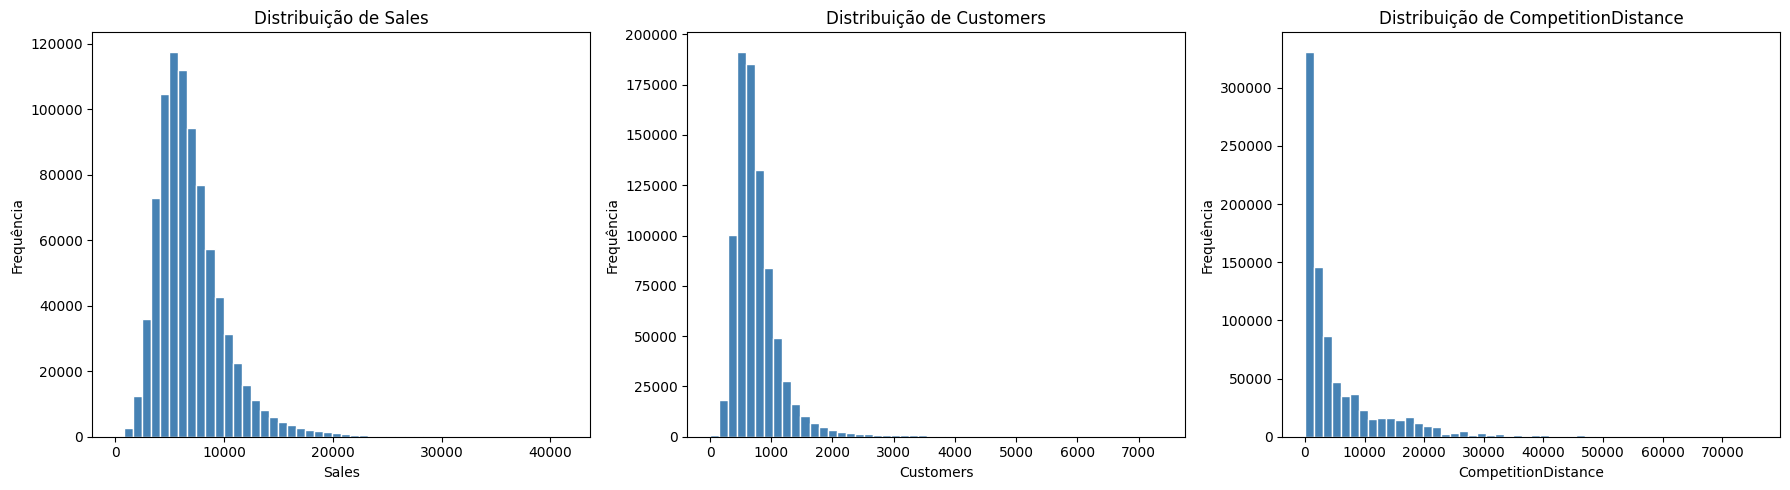

In [10]:
# As variáveis numéricas e contínuas a analisar
variaveis_numericas = ["Sales", "Customers", "CompetitionDistance"]

# Histogramas (apenas dias de loja aberta, para não distorcer com os zeros)
df_aberto = df[df["Open"] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, variaveis_numericas):
    ax.hist(df_aberto[col].dropna(), bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/histogramas_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

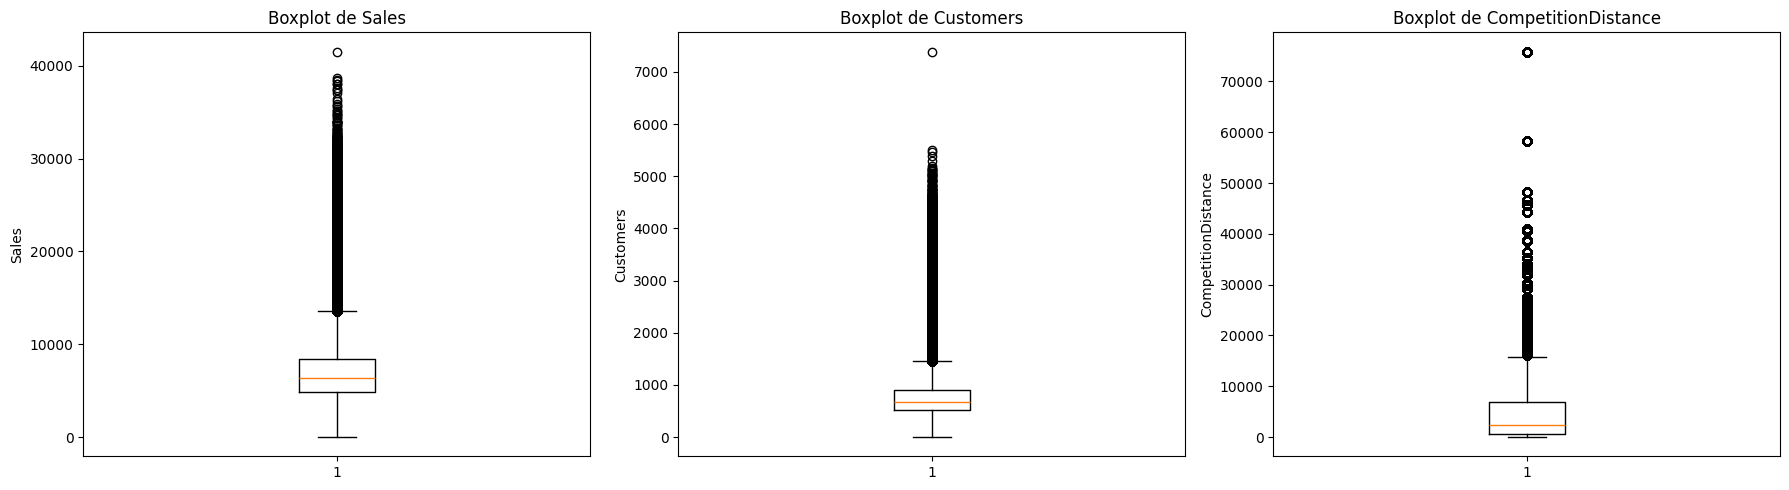

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, variaveis_numericas):
    ax.boxplot(df_aberto[col].dropna(), vert=True)
    ax.set_title(f"Boxplot de {col}")
    ax.set_ylabel(col)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/boxplots_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

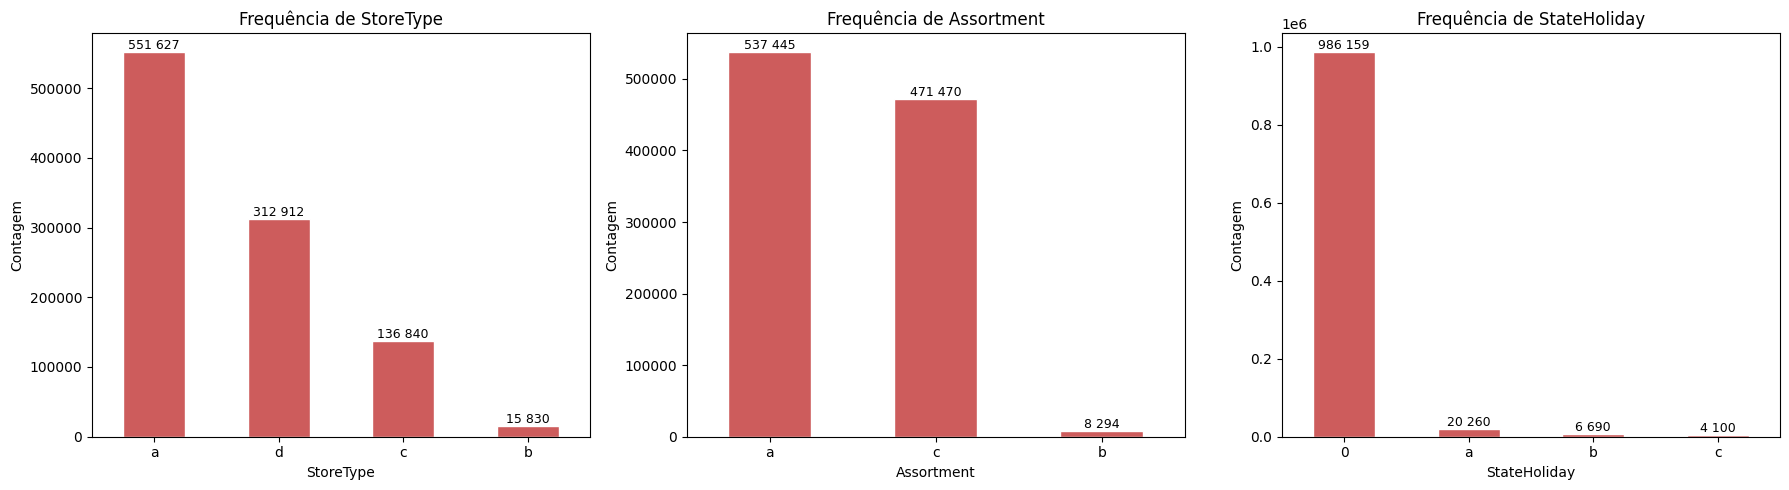

In [12]:
variaveis_categoricas = ["StoreType", "Assortment", "StateHoliday"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, variaveis_categoricas):
    contagem = df[col].value_counts()
    contagem.plot(kind="bar", ax=ax, color="indianred", edgecolor="white")
    ax.set_title(f"Frequência de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Contagem")
    ax.tick_params(axis="x", rotation=0)

    for i, valor in enumerate(contagem):
        ax.text(i, valor, f"{valor:,}".replace(",", " "), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/frequencia_categoricas.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise Univariada

### Variáveis Numéricas (Histogramas e Boxplots)

A variável alvo _`Sales`_ (considerando apenas os dias de loja aberta) apresenta uma distribuição com assimetria positiva. A maior parte dos dias concentra-se em vendas entre os 4000 e os 8000, mas existe uma cauda longa à direita, com dias de vendas que chegam aos 40000. O boxplot confirma este comportamento, mostrando uma grande quantidade de valores atípicos na zona superior. Esta assimetria sugere que poderá ser vantajoso aplicar uma transformação logarítmica à variável alvo na fase de modelação, de forma a aproximar a sua distribuição de uma forma mais simétrica e a reduzir o peso destes valores extremos.

A variável _`Customers`_ segue um padrão muito semelhante ao das vendas, com a maioria dos dias a registar entre 500 e 1000 clientes e uma cauda à direita de dias com afluência muito superior. Esta semelhança faz sentido com a forte ligação esperada entre o número de clientes e o volume de vendas.

A variável _`CompetitionDistance`_ apresenta a assimetria mais acentuada das três. A grande maioria das lojas tem concorrentes a curta distância, concentrando-se nos primeiros intervalos do histograma, mas existe um conjunto de lojas com concorrentes a distâncias muito elevadas, até cerca de 70000 metros, visíveis como valores atípicos no boxplot. Esta presença de valores extremos confirma a decisão, tomada na fase de limpeza, de imputar os valores em falta desta variável pela mediana e não pela média, por ser uma medida mais robusta a estes extremos.

### Variáveis Categóricas (Análise de Frequência)

A variável _`StoreType`_ está distribuída de forma desequilibrada. O tipo de loja "a" é a mais comum (551 627 registos), seguido do tipo "d" (312 912) e do tipo "c" (136 840), sendo o tipo "b" bastante raro (15 830 registos).

A variável _`Assortment`_, que indica a variedade de produtos, concentra-se em dois níveis: o "a" (537 445 registos) e o "c" (471 470), enquanto o nível "b" é quase residual (8 294 registos).

A variável _`StateHoliday`_ confirma que a esmagadora maioria dos dias não corresponde a qualquer feriado (986 159 registos com o valor "0"). Os dias de feriado são pouco frequentes, repartindo-se entre feriado estatal "a" (20 260), feriado de Páscoa "b" (6 690) e Natal "c" (4 100).

Esta raridade dos dias de feriado tem uma implicação relevante para a modelação. Como existem poucos exemplos destes dias, o modelo terá menos informação para aprender o comportamento das vendas em períodos festivos, o que poderá tornar as previsões menos fiáveis nessas alturas. Esta limitação deverá ser tida em conta na avaliação final do modelo.

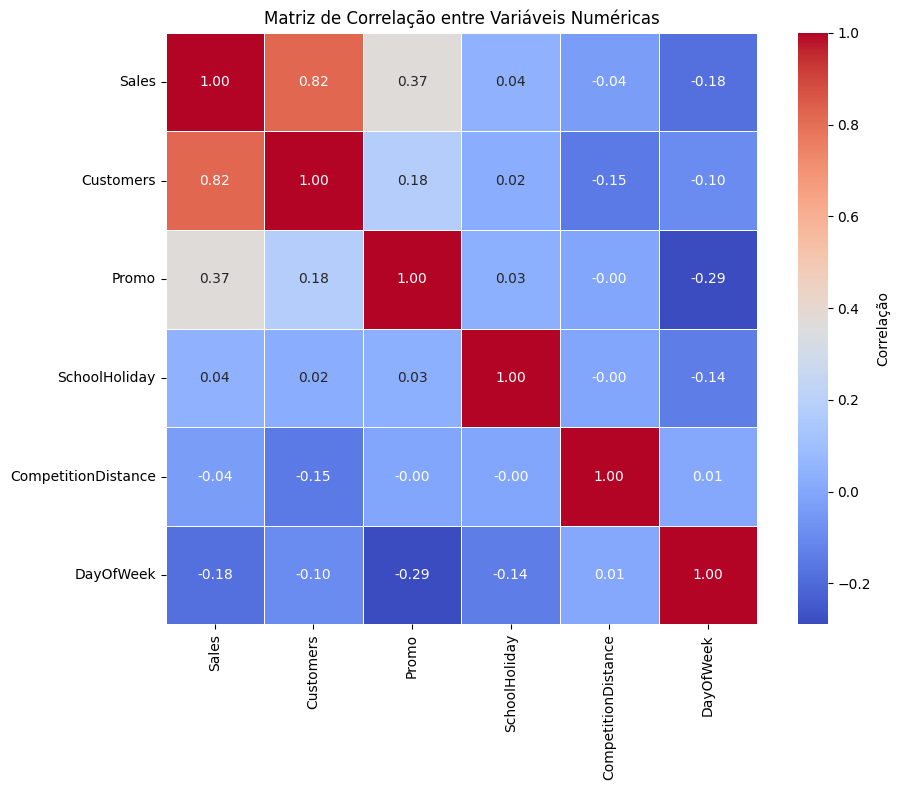

In [13]:
# Selecionar apenas as variáveis numéricas
colunas_numericas = ["Sales", "Customers", "Promo", "SchoolHoliday",
                     "CompetitionDistance", "DayOfWeek"]

# Calcular a matriz de correlação (apenas dias de loja aberta)
matriz_corr = df[df["Open"] == 1][colunas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f",
            square=True, linewidths=0.5, cbar_kws={"label": "Correlação"})
plt.title("Matriz de Correlação entre Variáveis Numéricas")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/matriz_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

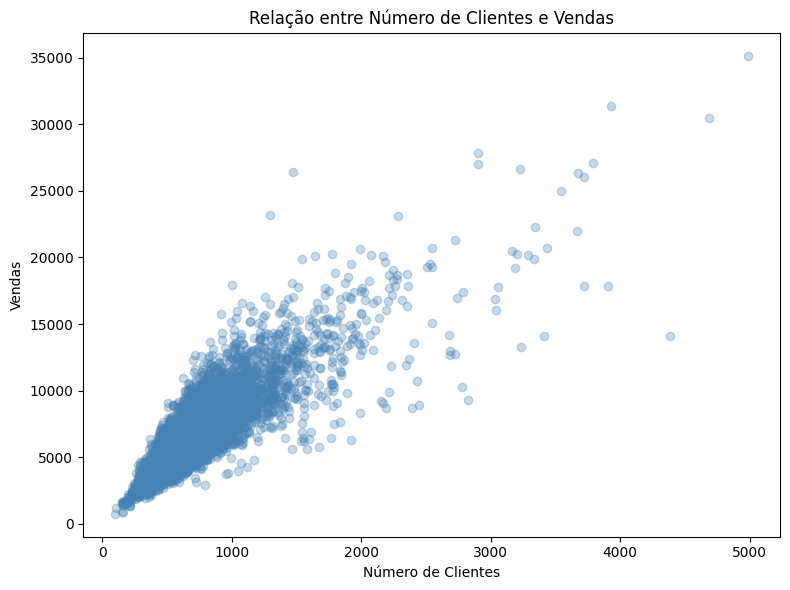

In [14]:
# Amostra aleatória para o scatter não ficar uma mancha ilegível
amostra = df[df["Open"] == 1].sample(n=5000, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(amostra["Customers"], amostra["Sales"], alpha=0.3, color="steelblue")
plt.title("Relação entre Número de Clientes e Vendas")
plt.xlabel("Número de Clientes")
plt.ylabel("Vendas")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/dispersao_clientes_vendas.png", dpi=150, bbox_inches="tight")
plt.show()

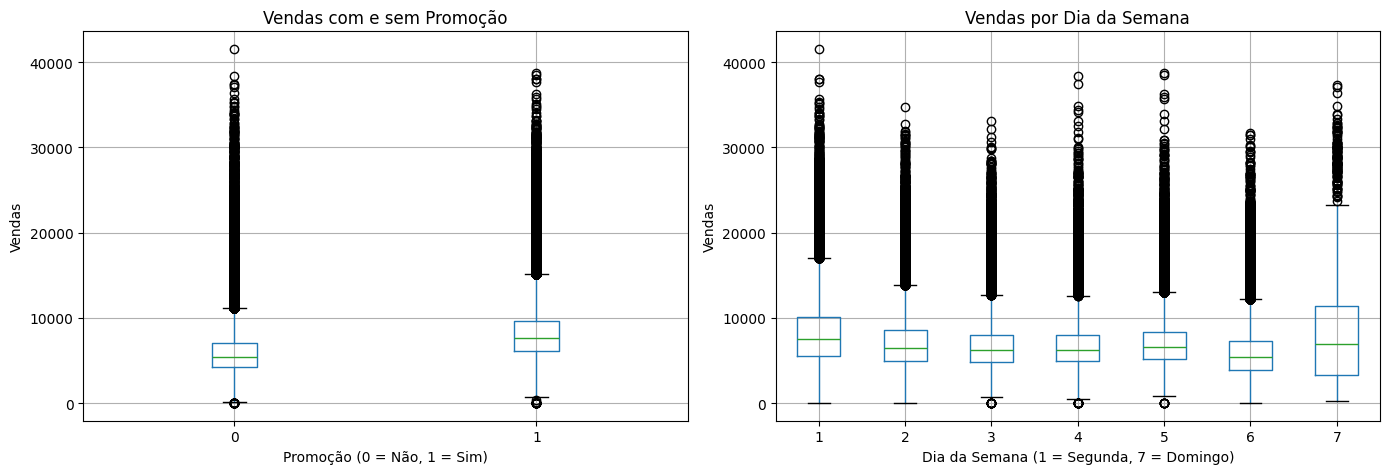

In [15]:
# Vendas com e sem promoção 
df_aberto = df[df["Open"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: vendas por promoção
df_aberto.boxplot(column="Sales", by="Promo", ax=axes[0])
axes[0].set_title("Vendas com e sem Promoção")
axes[0].set_xlabel("Promoção (0 = Não, 1 = Sim)")
axes[0].set_ylabel("Vendas")

# Boxplot: vendas por dia da semana
df_aberto.boxplot(column="Sales", by="DayOfWeek", ax=axes[1])
axes[1].set_title("Vendas por Dia da Semana")
axes[1].set_xlabel("Dia da Semana (1 = Segunda, 7 = Domingo)")
axes[1].set_ylabel("Vendas")

plt.suptitle("")  
plt.tight_layout()
plt.savefig("/kaggle/working/figures/vendas_promo_diasemana.png", dpi=150, bbox_inches="tight")
plt.show()

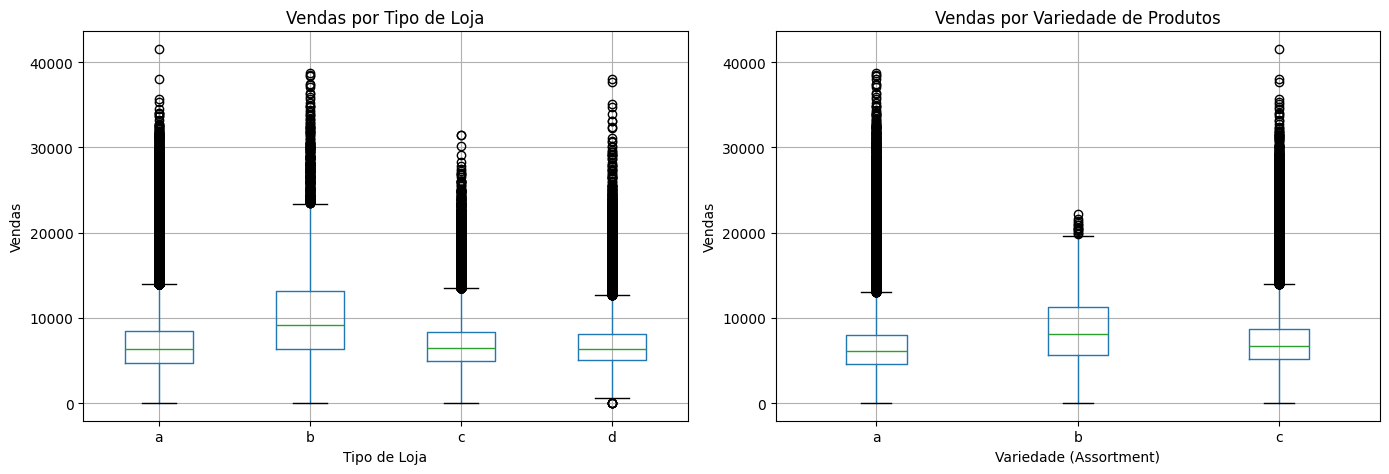

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: vendas por tipo de loja
df_aberto.boxplot(column="Sales", by="StoreType", ax=axes[0])
axes[0].set_title("Vendas por Tipo de Loja")
axes[0].set_xlabel("Tipo de Loja")
axes[0].set_ylabel("Vendas")

# Boxplot: vendas por variedade de produtos
df_aberto.boxplot(column="Sales", by="Assortment", ax=axes[1])
axes[1].set_title("Vendas por Variedade de Produtos")
axes[1].set_xlabel("Variedade (Assortment)")
axes[1].set_ylabel("Vendas")

plt.suptitle("")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/vendas_tipoloja_variedade.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise Bivariada (Correlações e Dispersão)

A matriz de correlação e o gráfico de dispersão permitem identificar as relações entre as variáveis numéricas e o volume de vendas. Destacam-se três conclusões principais.

### Conclusão 1: O número de clientes é o fator mais associado às vendas

A correlação entre o número de clientes e as vendas é de 0,82, a mais forte de toda a matriz. O gráfico de dispersão confirma visualmente esta relação, mostrando uma tendência crescente: quanto mais clientes entram na loja, maiores são as vendas. Apesar de forte, esta relação tem uma limitação prática importante. O número de clientes de um dia só é conhecido no final desse dia, pelo que não está disponível no momento de prever as vendas futuras. Por esse motivo, a variável _`Customers`_ não poderá ser utilizada como preditor no modelo, sendo aqui analisada apenas pelo seu valor descritivo.

### Conclusão 2: As promoções estão associadas a um aumento das vendas

A variável _`Promo`_ apresenta uma correlação positiva moderada com as vendas, de 0,37. Isto indica que os dias com promoção tendem a registar vendas superiores aos dias sem promoção, o que é coerente com o efeito esperado de uma campanha promocional. Esta é uma das relações mais úteis para a modelação, uma vez que a informação sobre a existência de promoção é conhecida antecipadamente e poderá ser usada como preditor.

### Conclusão 3: O dia da semana influencia negativamente as vendas
A variável _`DayOfWeek`_ apresenta uma correlação negativa fraca com as vendas, de -0,18. Como os dias da semana estão numerados de forma crescente até ao fim de semana, este sinal negativo sugere que as vendas tendem a ser mais baixas nos dias finais da semana, em parte explicado pelo encerramento de muitas lojas ao domingo. Esta relação é aprofundada na análise dos boxplots que se segue.

### Nota para a modelação
Com exceção da relação com o número de clientes, que não é aproveitável, as correlações das variáveis originais com as vendas são, no seu conjunto, fracas a moderadas. A distância ao concorrente, por exemplo, apresenta uma correlação praticamente nula (-0,04). Esta observação é relevante porque indica que as variáveis originais, por si só, poderão não ser suficientes para uma previsão de qualidade. Justifica-se, assim, a criação de novas variáveis na fase de engenharia de atributos, nomeadamente variáveis de calendário e de combinação de atributos, com o objetivo de captar padrões que as variáveis originais não conseguem expressar isoladamente.

## Qualidade dos Dados e Limpeza (EDA)

In [17]:
# Percentagem de nulos por coluna, no conjunto já juntado
percentagem_nulos = (df.isnull().sum() / len(df) * 100).round(2)
percentagem_nulos = percentagem_nulos[percentagem_nulos > 0].sort_values(ascending=False)

print("Percentagem de valores em falta por coluna:")
print(percentagem_nulos)

Percentagem de valores em falta por coluna:
Promo2SinceYear              49.94
Promo2SinceWeek              49.94
PromoInterval                49.94
CompetitionOpenSinceMonth    31.79
CompetitionOpenSinceYear     31.79
CompetitionDistance           0.26
dtype: float64


In [18]:
# CompetitionDistance: imputar pela mediana (robusta aos outliers que vimos no boxplot)
mediana_distancia = df["CompetitionDistance"].median()
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(mediana_distancia)

# Colunas de abertura do concorrente: nulo significa data desconhecida, preencher com 0
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)

# Colunas da Promo2: nulo significa que a loja não aderiu, preencher com 0
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)

# PromoInterval: nulo significa sem promoção contínua, preencher com a categoria "Nenhum"
df["PromoInterval"] = df["PromoInterval"].fillna("Nenhum")

# Confirmar que já não há nulos
print("Nulos restantes após imputação:")
print(df.isnull().sum().sum())

Nulos restantes após imputação:
0


In [19]:
# Dias de loja aberta mas com vendas zero (possível anomalia)
abertas_sem_vendas = df[(df["Open"] == 1) & (df["Sales"] == 0)]
print("Dias de loja aberta com vendas zero:", len(abertas_sem_vendas))

# Estatística da variável alvo para contextualizar os outliers
print("\nEstatísticas de Sales (dias de loja aberta):")
print(df[df["Open"] == 1]["Sales"].describe())

Dias de loja aberta com vendas zero: 54

Estatísticas de Sales (dias de loja aberta):
count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [20]:
# Confirmar os tipos das colunas críticas
print("Tipo de Date:", df["Date"].dtype)
print("Tipo de StateHoliday:", df["StateHoliday"].dtype)
print("\nValores únicos de StateHoliday:", df["StateHoliday"].unique())

Tipo de Date: datetime64[ns]
Tipo de StateHoliday: object

Valores únicos de StateHoliday: ['0' 'a' 'b' 'c']


## Qualidade dos Dados e Limpeza (Conclusões)

### Valores em Falta

Após a junção das tabelas, a análise da percentagem de valores em falta confirmou que estes se concentram nas variáveis provenientes da tabela das lojas. As colunas relativas à promoção contínua (_`Promo2SinceYear`_, _`Promo2SinceWeek`_ e _`PromoInterval`_) apresentam cerca de 50% de valores em falta, enquanto as colunas de abertura do concorrente (_`CompetitionOpenSinceMonth`_ e _`CompetitionOpenSinceYear`_) rondam os 32%. A _`CompetitionDistance`_ apresenta apenas 0,26% de valores em falta.

Importa notar que estas percentagens são elevadas porque cada loja se repete ao longo de centenas de dias no conjunto de dados. Um valor em falta numa loja replica-se, assim, por todos os seus registos diários. Confirmou-se que estes valores em falta não correspondem a erros de recolha, mas sim à ausência de evento, como lojas sem concorrente registado ou que não aderiram à promoção contínua.

A estratégia de imputação foi definida em função do significado de cada ausência. A _`CompetitionDistance`_ foi preenchida pela mediana, por ser uma medida robusta aos valores extremos identificados no boxplot. As colunas de abertura do concorrente e da promoção contínua foram preenchidas com o valor 0, e a _`PromoInterval`_ com a categoria "Nenhum", preservando a informação de que esses eventos não existem nessas lojas. Após a imputação, o conjunto de dados ficou sem qualquer valor em falta.

### Valores Atípicos

A análise dos boxplots revelou a presença de valores atípicos nas variáveis _`Sales`_, _`Customers`_ e _`CompetitionDistance`_. Após avaliação, concluiu-se que estes valores não representam erros, mas sim ocorrências reais, como dias de vendas elevadas associadas a promoções ou lojas efetivamente muito afastadas da concorrência. Por este motivo, optou-se por não os remover, uma vez que constituem informação legítima do comportamento das vendas. A forte assimetria da variável alvo será tratada na fase de modelação através de uma transformação logarítmica, abordagem preferível à eliminação de observações reais.

Foi ainda identificado um pequeno conjunto de 54 registos em que a loja se encontrava aberta mas não registou qualquer venda. Tratando-se de um número residual face aos mais de 844 mil dias de funcionamento e de um comportamento anómalo (uma loja aberta sem vendas), estes registos foram removidos, de forma a que o modelo aprenda apenas com dias de funcionamento normal.

### Correção de Tipos de Dados

A variável _`Date`_ foi convertida do formato de texto para o formato de data (`datetime`), passo essencial para a posterior criação de variáveis temporais. A variável _`StateHoliday`_, que apresentava uma mistura de tipos numéricos e de texto na leitura original, foi normalizada para texto, ficando com quatro categorias coerentes: sem feriado ("0"), feriado estatal ("a"), Páscoa ("b") e Natal ("c").

In [21]:
# Remover os 54 dias de loja aberta com vendas zero (comportamento anómalo)
df = df[~((df["Open"] == 1) & (df["Sales"] == 0))]
print("Registos após remoção:", df.shape[0])

Registos após remoção: 1017155


##  Engenharia de Atributos (Feature Engineering) 

In [22]:
# Variáveis de calendário, extraídas da Date
df["Ano"] = df["Date"].dt.year
df["Mes"] = df["Date"].dt.month
df["Dia"] = df["Date"].dt.day
df["SemanaDoAno"] = df["Date"].dt.isocalendar().week.astype(int)
df["FimDeSemana"] = (df["DayOfWeek"] >= 6).astype(int)  # 6=sábado, 7=domingo

In [23]:
# Indica se a loja está a decorrer um mês de promoção contínua (Promo2) nesse registo
# Cruza o mês atual com o intervalo de meses da PromoInterval da loja
meses_promo = {
    "Jan,Apr,Jul,Oct": [1, 4, 7, 10],
    "Feb,May,Aug,Nov": [2, 5, 8, 11],
    "Mar,Jun,Sept,Dec": [3, 6, 9, 12]
}

def promo2_ativa(linha):
    intervalo = linha["PromoInterval"]
    if intervalo == "Nenhum":
        return 0
    return 1 if linha["Mes"] in meses_promo.get(intervalo, []) else 0

df["Promo2Ativa"] = df.apply(promo2_ativa, axis=1)

In [24]:
novas_variaveis = ["Mes", "SemanaDoAno", "FimDeSemana", "Promo2Ativa"]

correlacoes = df[df["Open"] == 1][novas_variaveis + ["Sales"]].corr()["Sales"].drop("Sales")
print("Correlação das novas variáveis com Sales:")
print(correlacoes.sort_values(ascending=False))

Correlação das novas variáveis com Sales:
SemanaDoAno    0.074463
Mes            0.073589
Promo2Ativa   -0.068043
FimDeSemana   -0.151832
Name: Sales, dtype: float64


In [25]:
df = pd.get_dummies(df, columns=["StoreType", "Assortment", "StateHoliday"], drop_first=True)

## Engenharia de Atributos (Conclusões)

A análise bivariada mostrou que as variáveis originais, de forma isoladas, apresentam correlações fracas a moderadas com as vendas. Esta constatação justifica a criação de novos atributos capazes de captar padrões que as variáveis originais não expressam de forma direta. Foram criados dois tipos de variáveis novas.

### Variáveis de Calendário

A partir da variável _`Date`_ foram extraídas as seguintes variáveis temporais: _`Ano`_, _`Mes`_, _`Dia`_, _`SemanaDoAno`_ e _`FimDeSemana`_. Estas variáveis permitem ao modelo identificar padrões de sazonalidade, como a variação das vendas ao longo do ano ou a diferença de comportamento entre dias úteis e fins de semana. A variável _`FimDeSemana`_ assume o valor 1 nos dias de sábado e domingo e 0 nos restantes.

### Variáveis Derivadas de Combinação de Atributos

Para além da decomposição da data, foi criada a variável _`Promo2Ativa`_, que resulta do cruzamento de dois atributos: o mês de cada registo e o intervalo de meses de promoção contínua de cada loja (`PromoInterval`). Esta variável indica, para cada dia, se a loja se encontrava efetivamente num mês de promoção contínua. Trata-se de uma variável que transforma uma informação textual pouco utilizável numa informação binária diretamente aproveitável pelo modelo, traduzindo conhecimento do negócio numa nova característica.

### Verificação da Relação com a Variável Alvo

A correlação linear das novas variáveis com as vendas é, no seu conjunto, fraca. A variável _`FimDeSemana`_ apresenta a correlação mais expressiva (-0,15), confirmando que as vendas tendem a ser inferiores ao fim de semana. As restantes variáveis apresentam correlações próximas de zero.

Importa, contudo, interpretar estes valores com cuidado. A correlação linear apenas mede relações de proporcionalidade direta e não capta relações não lineares nem interações entre variáveis. Uma variável como o _`Mes`_, por exemplo, pode ter um efeito relevante nas vendas sem que esse efeito seja linear, uma vez que certos meses do ano concentram picos de procura. Os modelos baseados em árvores, que serão utilizados na fase de modelação, são capazes de aproveitar este tipo de relação, pelo que a baixa correlação linear não invalida a utilidade destas variáveis.

### Codificação das Variáveis Categóricas

As variáveis categóricas _`StoreType`_, _`Assortment`_ e _`StateHoliday`_ foram convertidas em formato numérico através de One-Hot Encoding, técnica adequada a variáveis sem ordem natural. Esta codificação cria uma coluna binária por categoria, permitindo que o modelo as interprete sem assumir qualquer hierarquia entre elas.

### Nota sobre o Escalonamento

O escalonamento das variáveis numéricas será realizado na fase de modelação e não nesta fase. Esta opção deve-se a dois motivos. Em primeiro lugar, o escalonamento deve ser ajustado apenas com os dados de treino e aplicado posteriormente aos dados de teste, de forma a evitar a fuga de informação do conjunto de teste para o de treino. Em segundo lugar, o modelo principal previsto baseia-se em árvores de decisão, que são indiferentes à escala das variáveis. O escalonamento será, ainda assim, preparado na fase seguinte, para permitir a comparação com eventuais modelos lineares.

In [26]:
# Verificar multicolinearidade entre as variáveis numéricas finais
import numpy as np

colunas_check = ["Sales", "Promo", "SchoolHoliday", "CompetitionDistance",
                "DayOfWeek", "Ano", "Mes", "Dia", "SemanaDoAno", "FimDeSemana", "Promo2Ativa"]

matriz = df[colunas_check].corr().abs()
# Mostrar apenas pares com correlação alta entre si (acima de 0,8), excluindo a diagonal
pares_altos = (matriz.where(~np.eye(len(matriz), dtype=bool)) > 0.8).sum().sum()
print("Número de pares com correlação acima de 0,8 entre si:", pares_altos // 2)
print("\nMatriz de correlação (valor absoluto):")
print(matriz.round(2))

Número de pares com correlação acima de 0,8 entre si: 1

Matriz de correlação (valor absoluto):
                     Sales  Promo  SchoolHoliday  CompetitionDistance  \
Sales                 1.00   0.45           0.09                 0.02   
Promo                 0.45   1.00           0.07                 0.00   
SchoolHoliday         0.09   0.07           1.00                 0.00   
CompetitionDistance   0.02   0.00           0.00                 1.00   
DayOfWeek             0.46   0.39           0.21                 0.00   
Ano                   0.02   0.02           0.04                 0.00   
Mes                   0.05   0.01           0.10                 0.00   
Dia                   0.01   0.11           0.03                 0.00   
SemanaDoAno           0.05   0.00           0.07                 0.00   
FimDeSemana           0.45   0.50           0.26                 0.00   
Promo2Ativa           0.04   0.00           0.02                 0.06   

                     DayOfW

In [27]:
# Remover variáveis que não devem ou não podem entrar no modelo
colunas_a_remover = [
    "Customers",       # não disponível no momento da previsão (fuga de informação)
    "Open",            # constante após filtrar dias de loja aberta
    "Date",            # já decomposta em Ano, Mes, Dia, SemanaDoAno e FimDeSemana
    "PromoInterval",   # já transformada em Promo2Ativa
    "Mes"              # redundante: correlação de 0,97 com SemanaDoAno
]

df_processado = df.drop(columns=colunas_a_remover)

print("Dimensão do dataset processado:", df_processado.shape)
print("\nColunas finais:")
print(df_processado.columns.tolist())

# Guardar o dataset completo 
df_processado.to_csv("/kaggle/working/rossmann_processado.csv", index=False)

# Guardar uma amostra de 15 linhas para o GitHub
amostra_github = df_processado.head(15)
amostra_github.to_csv("/kaggle/working/rossmann_processado_amostra.csv", index=False)
print("\nDataset completo e amostra de 15 linhas guardados com sucesso.")

Dimensão do dataset processado: (1017155, 24)

Colunas finais:
['Store', 'DayOfWeek', 'Sales', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Ano', 'Dia', 'SemanaDoAno', 'FimDeSemana', 'Promo2Ativa', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']

Dataset completo e amostra de 15 linhas guardados com sucesso.


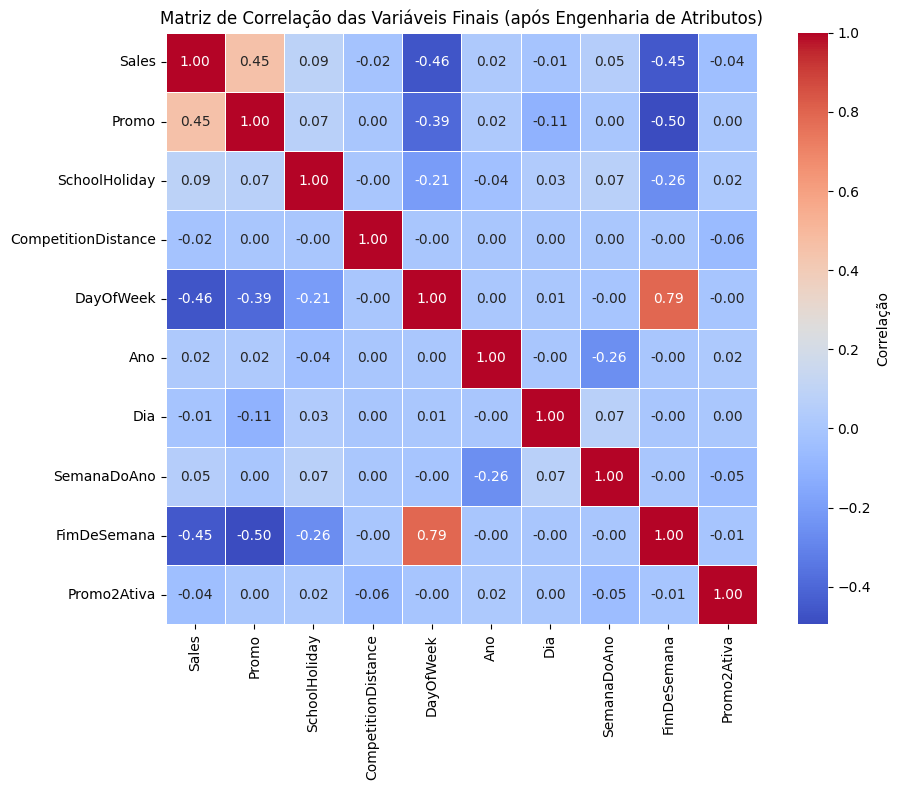

In [28]:
# Matriz de correlação visual das variáveis numéricas finais (após engenharia e limpeza)
colunas_finais = ["Sales", "Promo", "SchoolHoliday", "CompetitionDistance",
                  "DayOfWeek", "Ano", "Dia", "SemanaDoAno", "FimDeSemana", "Promo2Ativa"]

matriz_final = df_processado[colunas_finais].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_final, annot=True, cmap="coolwarm", fmt=".2f",
            square=True, linewidths=0.5, cbar_kws={"label": "Correlação"})
plt.title("Matriz de Correlação das Variáveis Finais (após Engenharia de Atributos)")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/matriz_correlacao_final.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusões da Fase de Exploração

A fase de exploração e preparação dos dados permitiu transformar dois ficheiros brutos num conjunto de dados coerente e pronto para a modelação, ao mesmo tempo que revelou padrões importantes sobre o comportamento das vendas.

A análise exploratória confirmou que a variável alvo apresenta uma forte assimetria positiva, com a maioria dos dias a registar vendas moderadas e uma minoria de dias com vendas muito elevadas. Identificou-se igualmente que o número de clientes é o fator mais fortemente associado às vendas, embora não possa ser utilizado na previsão por não estar disponível antecipadamente. As promoções e o dia da semana revelaram-se as relações mais úteis entre as variáveis originais, confirmando que as vendas sobem em dias de promoção e descem ao fim de semana.

Ao nível da qualidade dos dados, verificou-se que a tabela de vendas estava completa e que os valores em falta se concentravam nas características das lojas, correspondendo a ausências de evento e não a erros. Estes valores foram imputados com critério, preservando o seu significado. Foram ainda removidos cinquenta e quatro registos de lojas abertas sem qualquer venda, por constituírem um comportamento anómalo.

A engenharia de atributos constituiu o passo de maior valor acrescentado desta fase. Foram criadas variáveis de calendário, que captam a sazonalidade, e uma variável derivada da combinação de atributos, a _`Promo2Ativa`_, que traduz conhecimento do negócio numa nova característica. A verificação das correlações mostrou que, embora a relação linear destas variáveis com as vendas seja fraca, o seu valor reside na capacidade de os modelos baseados em árvores captarem relações não lineares que a correlação não revela.

Na preparação final, as variáveis categóricas foram codificadas em formato numérico e foram removidas as variáveis sem utilidade para a modelação, nomeadamente o número de clientes, por não estar disponível no momento da previsão, e a variável _`Mes`_, por estar quase perfeitamente correlacionada com a semana do ano. O conjunto de dados resultante encontra-se preparado para a fase de modelação, na qual serão aplicadas a transformação logarítmica da variável alvo e a divisão temporal entre treino e teste.

O conjunto de dados processado foi guardado na sua totalidade no ambiente Kaggle. Dada a sua dimensão superior a um milhão de registos, apenas uma amostra representativa foi incluída no repositório GitHub, em conformidade com os limites de tamanho da plataforma.